# Data Cleaning — Telco Customer Churn
**Notebook:** 02_data_cleaning.ipynb  
**Dataset:** WA_Fn-UseC_-Telco-Customer-Churn.csv  
**Goal:** Systematically identify and fix data quality issues before analysis and modelling.

---

## Table of Contents
1. [Import Libraries](#1-import-libraries)
2. [Load Dataset](#2-load-dataset)
3. [Dataset Overview](#3-dataset-overview)
4. [Missing Value Analysis](#4-missing-value-analysis)
5. [Data Type Validation](#5-data-type-validation)
6. [Duplicate Analysis](#6-duplicate-analysis)
7. [Category Validation](#7-category-validation)
8. [Numerical Validation](#8-numerical-validation)
9. [Data Cleaning Summary](#9-data-cleaning-summary)
10. [Save Cleaned Dataset](#10-save-cleaned-dataset)

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully.")
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"seaborn : {sns.__version__}")

Libraries imported successfully.
pandas  : 3.0.4
numpy   : 2.4.6
seaborn : 0.13.2


## 2. Load Dataset

In [2]:
RAW_DATA_PATH = r"D:\Telco_Customer_Churn\data\raw_data\WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(RAW_DATA_PATH)

print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset loaded successfully.
Shape: 7043 rows x 21 columns


In [3]:
# Preview first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Dataset Overview

Quick inspection of shape, columns, data types, and general info.

In [4]:
# Shape
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (7043, 21)


In [5]:
# Column names
print("Columns:")
for col in df.columns:
    print(f"  - {col}")

Columns:
  - customerID
  - gender
  - SeniorCitizen
  - Partner
  - Dependents
  - tenure
  - PhoneService
  - MultipleLines
  - InternetService
  - OnlineSecurity
  - OnlineBackup
  - DeviceProtection
  - TechSupport
  - StreamingTV
  - StreamingMovies
  - Contract
  - PaperlessBilling
  - PaymentMethod
  - MonthlyCharges
  - TotalCharges
  - Churn


In [6]:
# Data types
print("Data Types:")
print(df.dtypes)

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [7]:
# Basic info — non-null counts + dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 4. Missing Value Analysis

We check for both `NaN` and disguised missing values (e.g. blank strings `" "`).

In [8]:
# --- 4a. Standard NaN missing values ---
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct
}).query('`Missing Count` > 0')

if missing_df.empty:
    print("No standard NaN missing values found.")
else:
    print(missing_df)

No standard NaN missing values found.


In [9]:
# --- 4b. Detect disguised missing values (blank strings) in object columns ---
print("Blank string counts per object column:")
for col in df.select_dtypes(include='object').columns:
    blank_count = (df[col].str.strip() == '').sum()
    if blank_count > 0:
        print(f"  {col}: {blank_count} blank entries")
print("Done.")

Blank string counts per object column:
  TotalCharges: 11 blank entries
Done.


In [10]:
# --- 4c. Investigate: Who are the rows with blank TotalCharges? ---
blank_mask = df['TotalCharges'].str.strip() == ''
print(f"Rows with blank TotalCharges: {blank_mask.sum()}")
df[blank_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Rows with blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


### Decision

| Column | Issue | Action | Business Justification |
|---|---|---|---|
| `TotalCharges` | 11 blank strings (disguised NaN) | Convert to `float`, fill NaN with `0` | All 11 rows have `tenure = 0` — new customers with no charges yet. Filling with `0` is logically correct. |

## 5. Data Type Validation

Check each column's dtype, identify mismatches, and correct them.

In [12]:
# --- 5a. Summary of current data types (dynamic) ---
dtype_summary = pd.DataFrame({
    'Column' : df.columns.tolist(),
    'Dtype'  : df.dtypes.astype(str).tolist(),
})

# Flag columns that appear to have wrong types
def flag_type(col, dtype):
    suspected_numeric = ['TotalCharges']          # known issue column
    if col in suspected_numeric and dtype == 'object':
        return '⚠️  Should be numeric'
    return '✅'

dtype_summary['Status'] = [
    flag_type(col, dtype)
    for col, dtype in zip(dtype_summary['Column'], dtype_summary['Dtype'])
]

print(dtype_summary.to_string(index=False))

          Column   Dtype Status
      customerID     str      ✅
          gender     str      ✅
   SeniorCitizen   int64      ✅
         Partner     str      ✅
      Dependents     str      ✅
          tenure   int64      ✅
    PhoneService     str      ✅
   MultipleLines     str      ✅
 InternetService     str      ✅
  OnlineSecurity     str      ✅
    OnlineBackup     str      ✅
DeviceProtection     str      ✅
     TechSupport     str      ✅
     StreamingTV     str      ✅
 StreamingMovies     str      ✅
        Contract     str      ✅
PaperlessBilling     str      ✅
   PaymentMethod     str      ✅
  MonthlyCharges float64      ✅
    TotalCharges     str      ✅
           Churn     str      ✅


In [13]:
# --- 5b. Fix 1: Convert TotalCharges from object → float ---
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

print("TotalCharges dtype after conversion:", df['TotalCharges'].dtype)
print("Remaining NaN in TotalCharges:", df['TotalCharges'].isna().sum())

TotalCharges dtype after conversion: float64
Remaining NaN in TotalCharges: 0


In [14]:
# --- 5c. Verify all dtypes after conversion ---
print("Updated Data Types:")
print(df.dtypes)

Updated Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


## 6. Duplicate Analysis

Check for both fully duplicate rows and duplicate customer IDs.

In [15]:
# --- 6a. Check fully duplicate rows ---
dup_rows = df.duplicated().sum()
print(f"Fully duplicate rows: {dup_rows}")

# --- 6b. Check duplicate customerIDs ---
dup_ids = df['customerID'].duplicated().sum()
print(f"Duplicate customerIDs: {dup_ids}")
print(f"Total unique customers: {df['customerID'].nunique()}")

Fully duplicate rows: 0
Duplicate customerIDs: 0
Total unique customers: 7043


### Decision

| Check | Result | Action |
|---|---|---|
| Fully duplicate rows | 0 | No action needed |
| Duplicate customerIDs | 0 | No action needed |

> Each row represents a unique customer. No deduplication required.

## 7. Category Validation

Inspect unique values in object columns, check for inconsistent labels, and verify logical service dependencies.

In [16]:
# --- 7a. Unique values per object column (skip high-cardinality columns) ---
for col in df.select_dtypes(include='object').columns:
    n = df[col].nunique()
    if n <= 20:
        print(f"\n{col} ({n} unique):")
        print(f"  {sorted(df[col].dropna().unique().tolist())}")
    else:
        print(f"\n{col}: {n} unique values — skipped (high cardinality)")
    print("-" * 55)


customerID: 7043 unique values — skipped (high cardinality)
-------------------------------------------------------

gender (2 unique):
  ['Female', 'Male']
-------------------------------------------------------

Partner (2 unique):
  ['No', 'Yes']
-------------------------------------------------------

Dependents (2 unique):
  ['No', 'Yes']
-------------------------------------------------------

PhoneService (2 unique):
  ['No', 'Yes']
-------------------------------------------------------

MultipleLines (3 unique):
  ['No', 'No phone service', 'Yes']
-------------------------------------------------------

InternetService (3 unique):
  ['DSL', 'Fiber optic', 'No']
-------------------------------------------------------

OnlineSecurity (3 unique):
  ['No', 'No internet service', 'Yes']
-------------------------------------------------------

OnlineBackup (3 unique):
  ['No', 'No internet service', 'Yes']
-------------------------------------------------------

DeviceProtection (3

In [17]:
# --- 7b. Verify logical dependencies: services dependent on InternetService ---
# Columns that should be 'No internet service' when InternetService = 'No'
internet_dependent_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

no_internet_mask = df['InternetService'] == 'No'

print("Checking internet-dependent columns for customers with no internet service:")
for col in internet_dependent_cols:
    unexpected = df.loc[no_internet_mask, col].isin(['Yes', 'No']).sum()
    correct    = (df.loc[no_internet_mask, col] == 'No internet service').sum()
    print(f"  {col:25s} → Correct: {correct} | Unexpected (Yes/No): {unexpected}")

Checking internet-dependent columns for customers with no internet service:
  OnlineSecurity            → Correct: 1526 | Unexpected (Yes/No): 0
  OnlineBackup              → Correct: 1526 | Unexpected (Yes/No): 0
  DeviceProtection          → Correct: 1526 | Unexpected (Yes/No): 0
  TechSupport               → Correct: 1526 | Unexpected (Yes/No): 0
  StreamingTV               → Correct: 1526 | Unexpected (Yes/No): 0
  StreamingMovies           → Correct: 1526 | Unexpected (Yes/No): 0


In [18]:
# --- 7c. Verify PhoneService dependency: MultipleLines ---
no_phone_mask = df['PhoneService'] == 'No'
print("MultipleLines for customers with no phone service:")
print(df.loc[no_phone_mask, 'MultipleLines'].value_counts())

MultipleLines for customers with no phone service:
MultipleLines
No phone service    682
Name: count, dtype: int64


## 8. Numerical Validation

Summary statistics, range checks, impossible values, and outlier assessment.

In [19]:
# --- 8a. Summary statistics for numeric columns ---
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


In [20]:
# --- 8b. Range checks ---
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

expected_ranges = {
    'tenure'         : (0, 72),
    'MonthlyCharges' : (0, 200),
    'TotalCharges'   : (0, 10000)
}

print("Range Check:")
for col, (lo, hi) in expected_ranges.items():
    out_of_range = df[(df[col] < lo) | (df[col] > hi)].shape[0]
    print(f"  {col:20s} → Expected: [{lo}, {hi}]  |  Out-of-range: {out_of_range}")

Range Check:
  tenure               → Expected: [0, 72]  |  Out-of-range: 0
  MonthlyCharges       → Expected: [0, 200]  |  Out-of-range: 0
  TotalCharges         → Expected: [0, 10000]  |  Out-of-range: 0


In [21]:
# --- 8c. Impossible values check ---
print("Impossible Values:")
print(f"  Negative tenure         : {(df['tenure'] < 0).sum()}")
print(f"  Negative MonthlyCharges : {(df['MonthlyCharges'] < 0).sum()}")
print(f"  Negative TotalCharges   : {(df['TotalCharges'] < 0).sum()}")

# SeniorCitizen should only be 0 or 1
print(f"  SeniorCitizen values    : {df['SeniorCitizen'].unique().tolist()}")

Impossible Values:
  Negative tenure         : 0
  Negative MonthlyCharges : 0
  Negative TotalCharges   : 0
  SeniorCitizen values    : [0, 1]


In [22]:
# --- 8d. Outlier Assessment (IQR method) — identify only, do not remove ---
print("Outlier Assessment (IQR method):")
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"  {col:20s} → IQR bounds: [{lower:.2f}, {upper:.2f}]  |  Outliers: {outliers}")

Outlier Assessment (IQR method):
  tenure               → IQR bounds: [-60.00, 124.00]  |  Outliers: 0
  MonthlyCharges       → IQR bounds: [-46.02, 171.38]  |  Outliers: 0
  TotalCharges         → IQR bounds: [-4683.52, 8868.67]  |  Outliers: 0


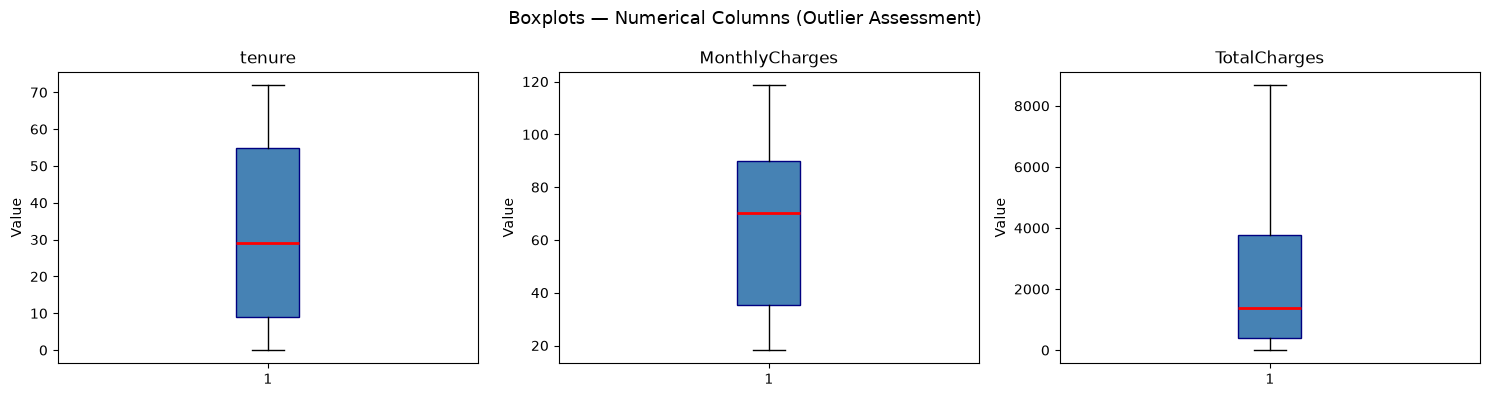

In [23]:
# --- 8e. Boxplots for visual outlier inspection ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots — Numerical Columns (Outlier Assessment)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Data Cleaning Summary

### Issues Found & Actions Taken

| # | Column | Issue | Action Taken | Business Justification |
|---|---|---|---|---|
| 1 | `TotalCharges` | Stored as `object` (string) instead of `float` | Converted using `pd.to_numeric(errors='coerce')` | Required for statistical analysis and modelling |
| 2 | `TotalCharges` | 11 blank string entries (disguised NaN) | Filled with `0.0` after conversion | All 11 rows have `tenure = 0`; new customers have incurred no charges |
| 3 | All columns | No standard `NaN` values found | No action needed | Dataset is clean in terms of null values |
| 4 | All rows | 0 duplicate rows | No action needed | Each row is a unique customer |
| 5 | `customerID` | 0 duplicate IDs | No action needed | One record per customer |
| 6 | Service columns | "No internet service" / "No phone service" labels consistent | No action needed | Logical dependencies are intact |
| 7 | Numeric columns | No impossible values (negatives, out-of-range) | No action needed | All values within expected business ranges |
| 8 | `TotalCharges` | Outliers detected via IQR | Noted — not removed | Outliers are valid high-value long-tenure customers |

### Final Dataset State
- **Rows:** 7,043
- **Columns:** 21
- **Missing Values:** 0
- **Duplicates:** 0
- **Ready for EDA:** ✅

In [24]:
# --- 9. Final state verification ---
print("=" * 50)
print("FINAL DATASET STATE")
print("=" * 50)
print(f"Shape              : {df.shape}")
print(f"Total Missing      : {df.isnull().sum().sum()}")
print(f"Duplicate Rows     : {df.duplicated().sum()}")
print(f"Duplicate IDs      : {df['customerID'].duplicated().sum()}")
print(f"TotalCharges dtype : {df['TotalCharges'].dtype}")
print("=" * 50)

FINAL DATASET STATE
Shape              : (7043, 21)
Total Missing      : 0
Duplicate Rows     : 0
Duplicate IDs      : 0
TotalCharges dtype : float64


## 10. Save Cleaned Dataset

Save the cleaned dataframe to `data/processed_data/` for use in subsequent notebooks.

In [25]:
# --- 10. Save cleaned dataset ---
PROCESSED_DIR  = r"D:\Telco_Customer_Churn\data\processed_data"
OUTPUT_FILE    = os.path.join(PROCESSED_DIR, "telco_cleaned.csv")

# Create directory if it doesn't exist
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Save
df.to_csv(OUTPUT_FILE, index=False)

print(f"Cleaned dataset saved to:")
print(f"  {OUTPUT_FILE}")
print(f"  Shape : {df.shape}")
print(f"  Size  : {os.path.getsize(OUTPUT_FILE) / 1024:.1f} KB")

Cleaned dataset saved to:
  D:\Telco_Customer_Churn\data\processed_data\telco_cleaned.csv
  Shape : (7043, 21)
  Size  : 956.0 KB
